# NODE – Neural Oblivious Decision Ensembles

This notebook demonstrates how to use the **NODE** module in Mother for tabular regression and classification.
NODE combines differentiable oblivious decision trees with deep learning, offering:

- **Competitive accuracy** on tabular data (comparable to gradient-boosted trees)
- **Multiple head architectures** – subset, linear, MLP, and flow (probabilistic)
- **Uncertainty quantification** – MC Dropout (all heads) + flow-based aleatoric uncertainty
- **Learned embeddings** for downstream tasks (UMAP, clustering, transfer learning)
- **Full sklearn compatibility** – `fit` / `predict` / `predict_proba` / pipelines
- **Hyperparameter tuning** via `MotherTuner` integration

---

### Architecture overview

```
Input Data → Embedding Layer → Dense ODST Blocks → Head → Predictions
                                                    ├─ subset  (default clf)
                                                    ├─ linear
                                                    ├─ mlp     (default reg)
                                                    └─ flow    (probabilistic, reg only)
```

### Table of contents

| # | Section | |
|---|---------|---|
| 1 | Architecture Deep Dive | Sparse activations, ODST trees, dense connections |
| 2 | Quick Start – Regression | Fit a NODE regressor in 5 lines |
| 3 | Quick Start – Classification | Binary and multiclass |
| 4 | Head Types Compared | subset · linear · mlp · flow |
| 5 | Flow Head – Probabilistic Regression | Sampling, density plots |
| 6 | Uncertainty Estimation | MC Dropout, flow, combined decomposition |
| 7 | Learned Embeddings & UMAP | Visualise tree representations |
| 8 | Multi-Target Regression | Multiple outputs, NaN masking |
| 9 | Class Weights & Imbalanced Data | Weighted classification |
| 10 | Multi-Label Classification | BCEWithLogitsLoss multi-label |
| 11 | Standalone Heads | MLPHeadRegressor · MLPHeadClassifier · FlowHeadRegressor |
| 12 | SHAP Explanations | GradientExplainer, KernelExplainer, waterfall |
| 13 | Advanced Topics | DataFrame/categorical support, embeddings→head pipeline, skorch, device |
| 14 | Hyperparameter Tuning with MotherTuner | Optuna integration |

---
## 1  Architecture Deep Dive

### Sparse Activations

NODE uses **sparse** activation functions that produce exact zeros, making trees naturally select only a few features per split:

| Function | Role | Description |
|----------|------|-------------|
| `entmax15` | Feature selection (`choice_function`) | Projects onto the 1.5-simplex — produces exact zeros |
| `sparsemax` | Feature selection (alternative) | Projects onto the probability simplex |
| `entmoid15` | Bin boundaries (`bin_function`) | Sparse sigmoid-like |
| `sparsemoid` | Bin boundaries (alternative) | Hard sigmoid variant |

The defaults (`entmax15` + `entmoid15`) mean each tree only attends to a small subset of features, improving interpretability.

### ODST — Oblivious Decision Stump Trees

Each tree is **oblivious**: all nodes at the same depth share the same split feature and threshold.
This makes each tree equivalent to a lookup table of size $2^{\text{depth}}$.

$$\text{output} = \sum_{l=1}^{2^d} w_l \cdot \mathbb{1}[\text{sample reaches leaf } l]$$

where $w_l$ is the learned response vector and the indicator is **soft** (differentiable) via the bin function.

### Dense Connections

The `DenseODSTBlock` stacks ODST layers with DenseNet-style connections:

```
Layer 1 input:  [X]           →  output h₁
Layer 2 input:  [X, h₁]      →  output h₂
Layer 3 input:  [X, h₁, h₂]  →  output h₃
```

Later layers see everything earlier layers learned, enabling iterative refinement.

### Constructor parameter reference

#### NODERegressor (key parameters)

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `num_trees` | int | 2048 | Trees in the ensemble |
| `depth` | int | 6 | Tree depth ($2^d$ leaves each) |
| `num_layers` | int | 1 | Stacked ODST layers |
| `head_type` | str | `"mlp"` | `"subset"` / `"linear"` / `"mlp"` / `"flow"` |
| `mlp_hidden_dims` | list | `[128,64,32]` | MLP head layer sizes |
| `flow_type` | str | `"NICE"` | `"GMM"` / `"NICE"` / `"RealNVP"` / `"NAF"` / `"UNAF"` / `"NSF"` / `"BPF"` (zuko) |
| `flow_transforms` | int | 3 | Number of flow layers (NICE, RealNVP, NAF, UNAF) |
| `flow_bins` | int | 8 | Spline bins (NSF only) |
| `input_dropout` | float | 0.1 | Input dropout (feeds MC-Dropout UQ) |
| `tree_dropout` | float | 0.0 | Dropout on whole tree outputs |
| `mlp_dropout` | float | 0.1 | Dropout in MLP head |
| `max_epochs` | int | 100 | Training epochs |
| `lr` | float | 0.01 | Learning rate |
| `batch_size` | int | 128 | Batch size |
| `target_type` | str | `"single_target"` | `"single_target"` or `"multi_target"` |
| `task_weights` | list | None | Per-target loss weights |

#### NODEClassifier differences

| Parameter | Regressor default | Classifier default |
|-----------|-------------------|-------------------|
| `head_type` | `"mlp"` | `"subset"` |
| `input_dropout` | 0.1 | 0.0 |
| `criterion` | `MSELoss` | `CrossEntropyLoss` |
| Flow head | ✅ supported | ❌ not supported |

> **Note.** There is no `CNF`/`MAF` flow — the supported `zuko` flows are exactly `GMM`, `NICE`, `RealNVP`, `NAF`, `UNAF`, `NSF`, `BPF`, and the default is **`NICE`**.


## Setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error, accuracy_score

# NODE
from mother.ml.models.m_node import NODERegressor, NODEClassifier

# Standalone heads
from mother.ml.models.m_heads import (
    MLPHeadRegressor,
    MLPHeadClassifier,
    FlowHeadRegressor,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


### Helper – synthetic datasets

In [2]:
def get_regression_data(n=400, n_features=10):
    """Create a simple regression dataset."""
    X, y = make_regression(
        n_samples=n,
        n_features=n_features,
        n_informative=6,
        noise=10,
        random_state=RANDOM_STATE,
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )
    # Standardise targets (important for flow heads)
    y_scaler = StandardScaler()
    y_train = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_test = y_scaler.transform(y_test.reshape(-1, 1)).ravel()
    return (
        X_train.astype(np.float32),
        X_test.astype(np.float32),
        y_train.astype(np.float32),
        y_test.astype(np.float32),
        y_scaler,
    )


def get_classification_data(n=400, n_features=10, n_classes=2, weights=None):
    """Create a classification dataset."""
    X, y = make_classification(
        n_samples=n,
        n_features=n_features,
        n_informative=6,
        n_redundant=2,
        n_classes=n_classes,
        random_state=RANDOM_STATE,
        weights=weights,
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )
    return X_train.astype(np.float32), X_test.astype(np.float32), y_train, y_test

---
## 2  Quick Start – Regression

In [3]:
X_train, X_test, y_train, y_test, y_scaler = get_regression_data()

reg = NODERegressor(
    num_trees=256,
    depth=4,
    num_layers=1,
    head_type="mlp",
    max_epochs=20,
    lr=0.01,
    device="cpu",
)
reg.fit(X_train, y_train)

preds = reg.predict(X_test)
print(f"R² = {r2_score(y_test, preds):.4f}")
print(f"RMSE = {root_mean_squared_error(y_test, preds):.4f}")


Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1        1.6995  0.5334
      2        0.5643  0.1050
      3        0.4946  0.1014
      4        0.3742  0.1018
      5        0.3221  0.1037
      6        0.2666  0.1106
      7        0.2918  0.1008
      8        0.2236  0.0952
      9        0.2336  0.0971
     10        0.2677  0.1029
     11        0.2773  0.1676
     12        0.1985  0.1287
     13        0.1999  0.1968
     14        0.1955  0.1316
     15        0.1508  0.1290
     16        0.2137  0.1590
     17        0.2012  0.1541
     18        0.1847  0.1140
     19        0.1731  0.1730
     20        0.1638  0.1134
R² = 0.9710
RMSE = 0.1485


In [4]:
# Inspect the full PyTorch module tree (ODST ensemble → MLP head)
reg.module_

CompletePyTorchTabularNODE(
  (dense_block): DenseODSTBlock(
    (0): ODST(in_features=10, num_trees=256, depth=4, tree_dim=4, flatten_output=True)
  )
  (embedding_layer): Embedding1dLayer()
  (head): MLPHead(
    (mlp): Sequential(
      (0): Linear(in_features=1024, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=64, out_features=32, bias=True)
      (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (10): ReLU()
      (11): Dropout(p=0.1, inplace=False)
      (12): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)

---
## 3  Quick Start – Classification

In [5]:
X_train_c, X_test_c, y_train_c, y_test_c = get_classification_data()

clf = NODEClassifier(
    num_trees=256,
    depth=4,
    num_layers=1,
    head_type="subset",  # default for classification
    input_dropout=0.1,  # enables MC-Dropout uncertainty
    max_epochs=20,
    lr=0.01,
    device="cpu",
)
clf.fit(X_train_c, y_train_c)

preds_c = clf.predict(X_test_c)
probas = clf.predict_proba(X_test_c)

print(f"Accuracy = {accuracy_score(y_test_c, preds_c):.4f}")
print(f"Probabilities shape: {probas.shape}")

Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.


  epoch    train_loss     dur
-------  ------------  ------
      1        0.6915  0.8647
      2        0.6798  0.1111
      3        0.6696  0.1682
      4        0.6592  0.1533
      5        0.6476  0.1270
      6        0.6349  0.1707
      7        0.6239  0.1667
      8        0.6096  0.2059
      9        0.5994  0.1859
     10        0.5846  0.1726
     11        0.5777  0.1750
     12        0.5558  0.1696
     13        0.5384  0.2206
     14        0.5282  0.1667
     15        0.5235  0.1767
     16        0.5056  0.1740
     17        0.4924  0.1852
     18        0.4894  0.1776
     19        0.4704  0.1743
     20        0.4669  0.1747
Accuracy = 0.7625
Probabilities shape: (80, 2)


In [6]:
# Architecture with subset head (default for classification)
clf.module_

CompletePyTorchTabularNODE(
  (dense_block): DenseODSTBlock(
    (0): ODST(in_features=10, num_trees=256, depth=4, tree_dim=5, flatten_output=True)
  )
  (embedding_layer): Embedding1dLayer()
  (head): Lambda()
)

---
## 4  Head Types Compared

NODE supports four head architectures.  Each one converts the tree ensemble output into final predictions.

| Head | How it works | Default for | Flow-based UQ? |
|------|-------------|-------------|----------------|
| **subset** | Averages a learned subset of tree outputs | Classification | No |
| **linear** | Single linear layer on flattened tree outputs | – | No |
| **mlp** | Multi-layer perceptron on flattened tree outputs | Regression | No |
| **flow** | Conditional normalising flow on tree embeddings | – (reg only) | **Yes** |

Each head receives the same tree embeddings but produces predictions differently:

```
                    ODST Ensemble Output  [batch, num_trees × depth]
                              │
          ┌───────────┬───────┴────────┬──────────────┐
          ▼           ▼                ▼              ▼
     ┌─────────┐ ┌─────────┐   ┌────────────┐  ┌──────────────┐
     │ SUBSET  │ │ LINEAR  │   │    MLP     │  │     FLOW     │
     │         │ │         │   │            │  │              │
     │ Wᵢ·hᵢ  │ │  W·h+b  │   │ h→BN→Act  │  │  x ──► p(y|x)│
     │  avg    │ │         │   │  →Drop     │  │  conditional │
     │  pool   │ │         │   │  × layers  │  │  normalizing │
     │         │ │         │   │            │  │  flow        │
     └────┬────┘ └────┬────┘   └─────┬──────┘  └──────┬───────┘
          ▼           ▼              ▼                ▼
       ŷ ∈ ℝ      ŷ ∈ ℝᵈ        ŷ ∈ ℝᵈ       dist.sample()
```

$\hat{y}_{\text{subset}} = \frac{1}{|S|}\sum_{i \in S} w_i \cdot h_i \qquad \hat{y}_{\text{linear}} = W h + b \qquad \hat{y}_{\text{mlp}} = \text{MLP}(h)$

In [7]:
import gc

X_train, X_test, y_train, y_test, y_scaler = get_regression_data()

results = {}

for head in ["subset", "linear", "mlp", "flow"]:
    print(f"\n--- head_type = '{head}' ---")
    model = NODERegressor(
        num_trees=256,
        depth=4,
        head_type=head,
        flow_type="NSF",  # only used when head_type == "flow"
        max_epochs=20,
        lr=0.01,
        device="cpu",
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    results[head] = r2
    print(f"  R² = {r2:.4f}")
    del model
    gc.collect()

print("\n=== Summary ===")
for head, r2 in sorted(results.items(), key=lambda x: -x[1]):
    print(f"  {head:8s}  R² = {r2:.4f}")



--- head_type = 'subset' ---
Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1        0.9981  0.7704
      2        0.9647  0.2002
      3        0.9325  0.1565
      4        0.9012  0.1330
      5        0.8703  0.1920
      6        0.8344  0.2130
      7        0.8028  0.2160
      8        0.7667  0.2324
      9        0.7310  0.2493
     10        0.6801  0.2557
     11        0.6405  0.2557
     12        0.5910  0.3590
     13        0.5528  0.2972
     14        0.4904  0.3244
     15        0.4702  0.2927
     16        0.4176  0.4158
     17        0.3655  0.4094
     18        0.3466  0.3768
     19        0.3237  0.3236
     20        0.2785  1.0093
  R² = 0.7792

--- head_type = 'linear' ---
Re-initializing module because the following parameters were re-set: module__head_typ

---
## 5  Flow Head – Probabilistic Regression

The **flow head** models the full conditional distribution $p(y \mid x)$ using normalising flows.
This lets you:

- Draw samples from the predictive distribution
- Estimate quantiles, credible intervals, or density plots
- Decompose uncertainty into **aleatoric** (data) and **epistemic** (knowledge) components

### How normalizing flows work

A flow transforms a simple base distribution $z \sim \mathcal{N}(0, I)$ into a complex
target distribution through a chain of invertible transformations:

```
  z ~ N(0,I)  ──► T₁ ──► T₂ ──► T₃ ──►  y ~ p(y|x)
       │            │       │       │          │
   base dist   transform  ...   transform   learned
   (simple)    (invertible)      (invertible) distribution

```

The loss is the **negative log-likelihood** under the change-of-variables formula:

$$\log p(y \mid x) = \log p_z\bigl(T^{-1}(y)\bigr) + \sum_{k=1}^{K} \log \left|\det \frac{\partial T_k^{-1}}{\partial T_{k-1}}\right|$$

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \log p(y_i \mid x_i)$$

Supported flow types (via the [zuko](https://github.com/probabilists/zuko) library) — the
default is **`NICE`**:

| `flow_type` | Description | Notes |
|-------------|-------------|-------|
| `NICE` | Non-linear Independent Components Estimation | **Default** – simple and fast |
| `NSF` | Neural Spline Flow | **Recommended** – best quality/speed tradeoff (tune `flow_bins`) |
| `RealNVP` | Real-valued Non-Volume Preserving | Flexible affine coupling |
| `NAF` | Neural Autoregressive Flow | Very expressive (tune `flow_signal`) |
| `UNAF` | Unconstrained Neural Autoregressive Flow | Expressive, unconstrained |
| `BPF` | Bernstein Polynomial Flow | Monotonic spline-like (tune `flow_degree`) |
| `GMM` | Gaussian Mixture | Multi-modal targets (tune `flow_components`) |

> **Tip:** Always standardise your targets before training with a flow head for numerical stability
> (the `get_regression_data` helper already standardises `y`).


In [3]:
X_train, X_test, y_train, y_test, y_scaler = get_regression_data()

flow_model = NODERegressor(
    num_trees=256,
    depth=4,
    head_type="flow",
    flow_type="NSF",  # Neural Spline Flow (recommended)
    flow_transforms=3,
    flow_bins=8,
    input_dropout=0.1,  # enables MC Dropout for combined UQ
    max_epochs=20,
    lr=0.01,
    device="cpu",
)
flow_model.fit(X_train, y_train)

# Point predictions (mode of the distribution)
preds_flow = flow_model.predict(X_test)
print(f"Flow R² = {r2_score(y_test, preds_flow):.4f}")

Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1        7.6117  0.6801
      2        2.4865  0.1182
      3        1.8979  0.1246
      4        1.4690  0.1115
      5        1.0892  0.1336
      6        0.8859  0.1513
      7        0.5643  0.1159
      8        1.6312  0.1580
      9        0.8831  0.1758
     10        0.8727  0.2499
     11        0.6236  0.1684
     12        0.5506  0.1886
     13        0.3486  0.2748
     14        0.2185  0.2033
     15        0.2228  0.1827
     16        0.4231  0.2139
     17        0.3087  0.1528
     18        0.2391  0.1835
     19        0.2271  0.1880
     20        0.2077  0.2030
Flow R² = 0.9801


In [9]:
# Architecture with normalising-flow head (NSF)
flow_model.module_

CompletePyTorchTabularNODE(
  (dense_block): DenseODSTBlock(
    (0): ODST(in_features=10, num_trees=256, depth=4, tree_dim=4, flatten_output=True)
  )
  (embedding_layer): Embedding1dLayer()
  (head): FlowHead(
    (net): NSF(
      (transform): LazyComposedTransform(
        (0-2): 3 x ElementWiseTransform(
          (base): MonotonicRQSTransform(bins=8)
          (hyper): MLP(
            (0): Linear(in_features=1024, out_features=64, bias=True)
            (1): ReLU()
            (2): Linear(in_features=64, out_features=64, bias=True)
            (3): ReLU()
            (4): Linear(in_features=64, out_features=23, bias=True)
          )
        )
      )
      (base): UnconditionalDistribution(DiagNormal(loc: tensor([0.]), scale: tensor([1.])))
    )
  )
)

### 5.1  Sampling from the flow distribution

Access the underlying flow distribution to draw samples from $p(y \mid x)$ and visualise
the predictive density for individual test points.

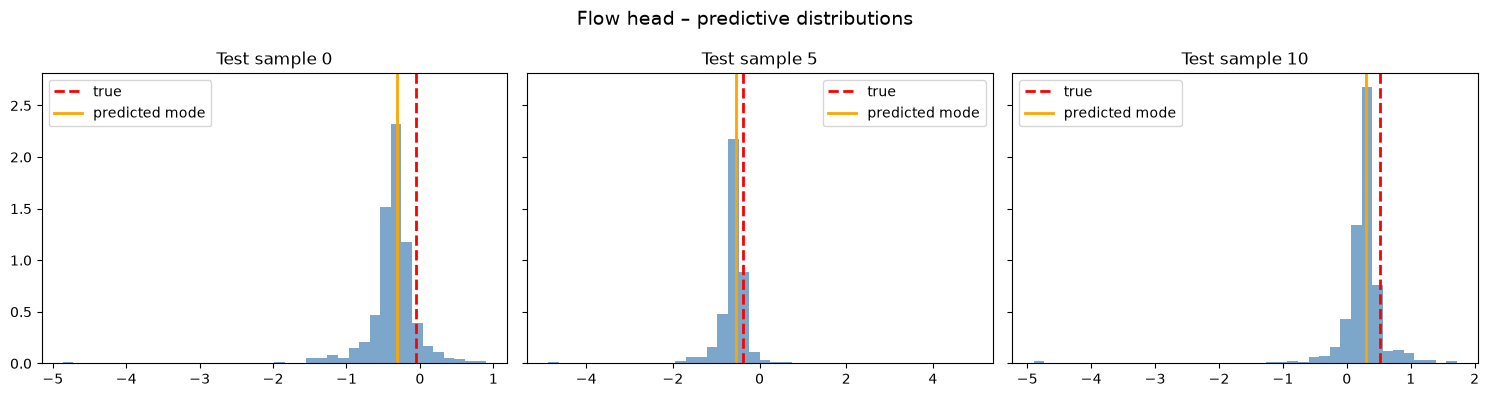

In [10]:
import torch

flow_model.module_.eval()

# Pick a few test points to visualise
idx = [0, 5, 10]
X_subset = X_test[idx]
X_tensor = torch.tensor(X_subset, dtype=torch.float32)

with torch.no_grad():
    dist = flow_model.module_(X_tensor)
    samples = dist.sample((500,)).squeeze(-1).cpu().numpy()  # (500, len(idx))

fig, axes = plt.subplots(1, len(idx), figsize=(5 * len(idx), 4), sharey=True)
for i, ax in enumerate(axes):
    ax.hist(samples[:, i], bins=40, density=True, alpha=0.7, color="steelblue")
    ax.axvline(y_test[idx[i]], color="red", ls="--", lw=2, label="true")
    ax.axvline(preds_flow[idx[i]], color="orange", ls="-", lw=2, label="predicted mode")
    ax.set_title(f"Test sample {idx[i]}")
    ax.legend()
fig.suptitle("Flow head – predictive distributions", fontsize=14)
plt.tight_layout()
plt.show()

---
## 6  Uncertainty Estimation

NODE supports three uncertainty modes, all accessed through the **standardised
`predict_uncertainty()` interface** (matching TabPFN, RandomForest, and CatBoost):

```
                          predict_uncertainty(X)
                                  │
                 ┌────────────────┼────────────────┐
                 ▼                ▼                ▼
          ┌────────────┐  ┌────────────┐  ┌─────────────────┐
          │ MC Dropout │  │   Flow     │  │    Combined     │
          │            │  │  Sampling  │  │  (Flow+Dropout) │
          │ N forward  │  │ draw from  │  │  MC passes ×    │
          │ passes w/  │  │ p(y|x) via │  │  flow samples   │
          │ stochastic │  │ learned    │  │  per pass       │
          │ dropout    │  │ distribtn  │  │                 │
          └─────┬──────┘  └─────┬──────┘  └───────┬─────────┘
                │               │                 │

                ▼               ▼                 ▼
           σ_epistemic     σ_aleatoric    epist + aleat
          (knowledge)       (data)         (decomposed)
```

| Method | Head types | What it captures | API |
|--------|-----------|-----------------|-----|
| **MC Dropout** | All (need `input_dropout > 0`) | Epistemic (knowledge) | `predict_uncertainty()` |
| **Flow sampling** | Flow only | Aleatoric (data) | `predict_uncertainty()` |
| **Combined decomposition** | Flow + dropout | Both, decomposed | `predict_with_combined_uncertainty()` |

**Key parameters** (same signature as TabPFN / RandomForest):

| Parameter | Default | Description |
|-----------|---------|-------------|
| `num_samples` | `100` | MC Dropout forward passes (or flow samples) |
| `return_quantiles` | `False` | If `True`, also return `(DataFrame, quantile_array)` |
| `quantiles` | `[0.25, 0.5, 0.75]` | Quantiles to compute (only when `return_quantiles=True`) |
| `uncertainty_for_opt` | `False` | If `True`, return only `total_uncertainty` as `pd.Series` |

### MC Dropout — the math

Given $N$ stochastic forward passes with different dropout masks $\theta_i$:

$\hat{y} = \frac{1}{N}\sum_{i=1}^{N} f_{\theta_i}(x) \qquad \sigma_{\text{epistemic}} = \sqrt{\frac{1}{N-1}\sum_{i=1}^{N} \bigl(f_{\theta_i}(x) - \hat{y}\bigr)^2}$

### Flow uncertainty — the math (BALD entropy decomposition)

The flow head models the full density $p(y\mid x)$, so instead of scoring a single
point (the mode) the decomposition uses the **whole** distribution via an
information-theoretic (BALD) split — the continuous twin of the classification
decomposition in §6.4. Treat the $T$ MC-dropout passes as an ensemble of flows
$\{p_t(y\mid x)\}$ and estimate differential entropies by Monte-Carlo,
$H[p]=-\mathbb{E}_{y\sim p}[\log p(y)]\approx-\frac{1}{S}\sum_s\log p(y_s)$, $y_s\sim p$:

$$
\underbrace{H\!\big[\tfrac1T\textstyle\sum_t p_t\big]}_{\text{total (mixture entropy)}}
=
\underbrace{\tfrac1T\textstyle\sum_t H[p_t]}_{\text{data (expected entropy, aleatoric)}}
+
\underbrace{\Big(H\!\big[\tfrac1T\textstyle\sum_t p_t\big]-\tfrac1T\textstyle\sum_t H[p_t]\Big)}_{\text{knowledge (mutual information, epistemic)}}
$$

The `knowledge` term is a **mutual information** — always $\ge 0$ by Jensen — so
`total = data + knowledge` holds exactly and `total ≥ data`. Because `data` and
`total` are *differential* entropies (nats), they **can be negative** for a peaked
flow; that is inherent to continuous uncertainty, not a bug (see §6.3).


### 6.1  MC Dropout uncertainty (any head)

In [11]:
X_train, X_test, y_train, y_test, y_scaler = get_regression_data()

model_mlp = NODERegressor(
    num_trees=256,
    depth=4,
    head_type="mlp",
    input_dropout=0.1,  # required for MC Dropout
    max_epochs=20,
    lr=0.01,
    device="cpu",
)
model_mlp.fit(X_train, y_train)

df_unc = model_mlp.predict_uncertainty(X_test, num_samples=30)
print(df_unc.head())
print(f"\nColumns: {list(df_unc.columns)}")

Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1        1.2938  0.7029
      2        0.5449  0.2308
      3        0.3945  0.1490
      4        0.2827  0.1465
      5        0.2408  0.2129
      6        0.2475  0.1613
      7        0.2089  0.1195
      8        0.2105  0.1501
      9        0.1895  0.2345
     10        0.2425  0.2038
     11        0.1796  0.1502
     12        0.1707  0.1283
     13        0.1966  0.2028
     14        0.2136  0.1286
     15        0.2060  0.1437
     16        0.1714  0.1402
     17        0.1233  0.1500
     18        0.1409  0.2052
     19        0.1462  0.1940
     20        0.2063  0.1808
       pred  mean_predictions  knowledge_uncertainty data_uncertainty  \
0  0.018520          0.018520               0.329848             None   
1 -0.889080  

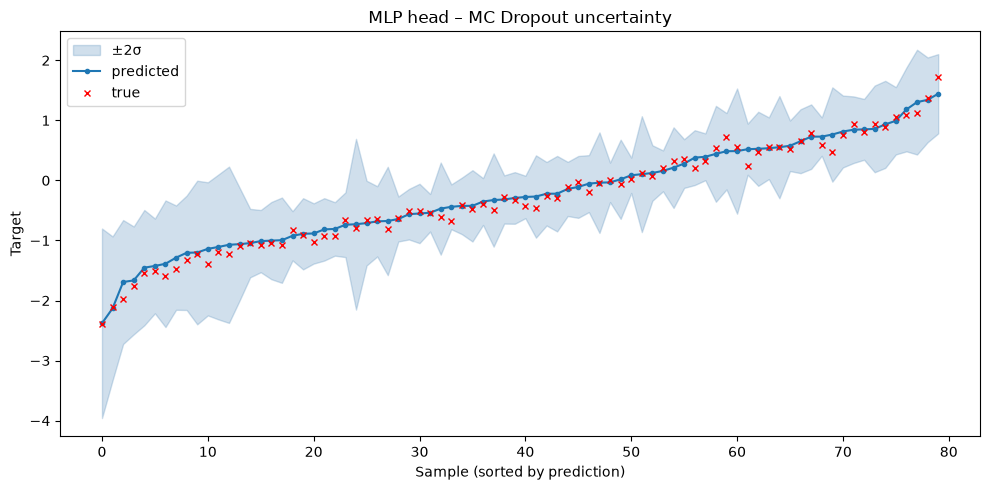

In [12]:
# Plot predictions with uncertainty bands
sort_idx = np.argsort(df_unc["mean_predictions"].values)
preds_sorted = df_unc["mean_predictions"].values[sort_idx]
unc_sorted = df_unc["total_uncertainty"].values[sort_idx]
true_sorted = y_test[sort_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(
    range(len(preds_sorted)),
    preds_sorted - 2 * unc_sorted,
    preds_sorted + 2 * unc_sorted,
    alpha=0.25,
    color="steelblue",
    label="±2σ",
)
ax.plot(preds_sorted, "o-", ms=3, label="predicted")
ax.plot(true_sorted, "x", ms=4, color="red", label="true")
ax.set_xlabel("Sample (sorted by prediction)")
ax.set_ylabel("Target")
ax.set_title("MLP head – MC Dropout uncertainty")
ax.legend()
plt.tight_layout()
plt.show()

#### How dropout controls uncertainty — the three knobs

NODE has **three independent dropout knobs**, each acting at a different stage and each
feeding Monte-Carlo (MC) dropout uncertainty. Turning any of them up injects more
stochasticity, so **higher dropout ⇒ more spread across MC passes ⇒ larger `total_uncertainty`**.

| Knob | Acts on | Regularises against |
|------|---------|---------------------|
| `input_dropout` | raw / embedded input features (inside every `DenseODSTBlock`) | over-reliance on any single feature |
| `tree_dropout` | **whole tree outputs** before the head (Bernoulli mask, inverted-dropout scaling) | over-reliance on any single tree |
| `mlp_dropout` | hidden units inside the MLP head (`nn.Dropout`) | head co-adaptation |

All three are gated on the module's `training` flag. For MC dropout, NODE keeps the model in
`eval()` (so **BatchNorm uses its running statistics and is never updated**) and switches on
**only** the dropout mechanisms — see §13.5. If *all* dropouts are 0, `predict_uncertainty`
falls back to a deterministic `predict()` (zero variance).

The cell below fits one model, then isolates each knob at inference and sweeps its rate to show
the monotonic variance ↑ relationship.


Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1        1.6191  0.2473
      2        0.5829  0.0614


      3        0.5296  0.1791
      4        0.4561  0.1434
      5        0.2863  0.0754
      6        0.2923  0.0442
      7        0.3121  0.0696
      8        0.2771  0.0857
      9        0.3116  0.0581
     10        0.2372  0.0656
     11        0.2026  0.0609
     12        0.2191  0.0509
     13        0.1859  0.0393
     14        0.1554  0.0433
     15        0.2344  0.0658
     16        0.1557  0.0413
     17        0.1979  0.0429
     18        0.1627  0.1203
     19        0.2251  0.0782
     20        0.1723  0.0867


No dropout configured in model (input_dropout, tree_dropout, mlp_dropout all 0). Falling back to deterministic predict() without uncertainty estimation. Set at least one dropout > 0 to enable Monte Carlo Dropout uncertainty.
No dropout configured in model (input_dropout, tree_dropout, mlp_dropout all 0). Falling back to deterministic predict() without uncertainty estimation. Set at least one dropout > 0 to enable Monte Carlo Dropout uncertainty.
No dropout configured in model (input_dropout, tree_dropout, mlp_dropout all 0). Falling back to deterministic predict() without uncertainty estimation. Set at least one dropout > 0 to enable Monte Carlo Dropout uncertainty.


dropout p            0.0     0.1     0.2     0.3     0.5
input_dropout      0.000   0.275   0.425   0.554   0.814
tree_dropout       0.000   0.091   0.132   0.168   0.254
mlp_dropout        0.000   0.199   0.307   0.419   0.692


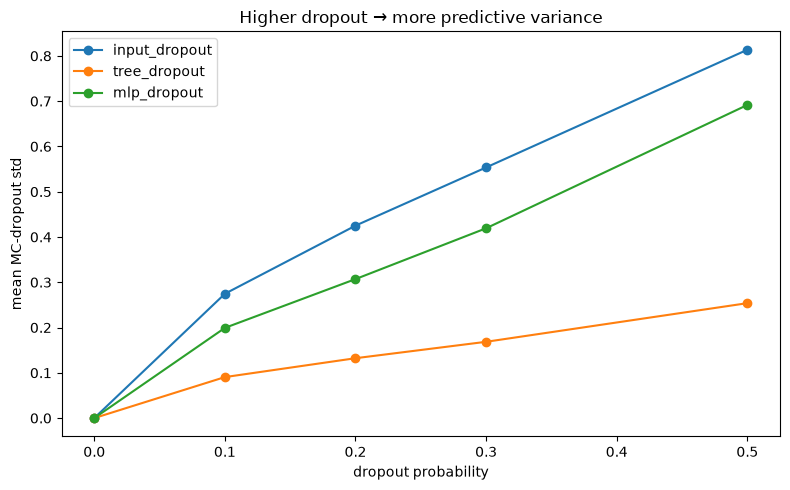


✅ Each dropout knob is deterministic at p=0 and increases variance monotonically.


In [13]:
import torch.nn as nn
from mother.ml.models.m_node_utils import DenseODSTBlock

X_train, X_test, y_train, y_test, y_scaler = get_regression_data()

# Fit one model with all three dropout paths active
reg_dp = NODERegressor(
    head_type="mlp",
    num_trees=64,
    depth=4,
    input_dropout=0.1,
    tree_dropout=0.1,
    mlp_dropout=0.1,
    max_epochs=20,
    lr=0.01,
    device="cpu",
)
reg_dp.fit(X_train, y_train)


def set_dropouts(est, *, input_dp, tree_dp, mlp_dp):
    """Override dropout rates on a fitted NODE model (to isolate one knob at inference)."""
    m = est.module_
    est.input_dropout = input_dp
    m.input_dropout = input_dp
    for sub in m.modules():
        if isinstance(sub, DenseODSTBlock):
            sub.input_dropout = input_dp
    m.tree_dropout = tree_dp
    m.mlp_dropout = mlp_dp
    for sub in m.modules():
        if isinstance(sub, nn.Dropout):
            sub.p = mlp_dp


def mean_mc_std(est, X, num_samples=100):
    """Mean MC-dropout std across the test set."""
    return float(np.mean(est._predict_uncertainty_mc_dropout(X, num_samples=num_samples, use_std=True)))


sweep = [0.0, 0.1, 0.2, 0.3, 0.5]
mechanisms = {
    "input_dropout": lambda p: dict(input_dp=p, tree_dp=0.0, mlp_dp=0.0),
    "tree_dropout": lambda p: dict(input_dp=0.0, tree_dp=p, mlp_dp=0.0),
    "mlp_dropout": lambda p: dict(input_dp=0.0, tree_dp=0.0, mlp_dp=p),
}

curves = {}
for name, cfg in mechanisms.items():
    stds = []
    for p in sweep:
        set_dropouts(reg_dp, **cfg(p))
        stds.append(mean_mc_std(reg_dp, X_test))
    curves[name] = stds

# Report + plot
print("dropout p ".ljust(16) + "".join(f"{p:>8}" for p in sweep))
for name, stds in curves.items():
    print(name.ljust(16) + "".join(f"{s:>8.3f}" for s in stds))

fig, ax = plt.subplots(figsize=(8, 5))
for name, stds in curves.items():
    ax.plot(sweep, stds, "o-", label=name)
ax.set_xlabel("dropout probability")
ax.set_ylabel("mean MC-dropout std")
ax.set_title("Higher dropout → more predictive variance")
ax.legend()
plt.tight_layout()
plt.show()

# Sanity checks: zero variance at p=0, and variance grows with p
for name, stds in curves.items():
    assert stds[0] < 1e-6, f"{name}: expected ~0 variance at p=0"
    assert stds[-1] > stds[1], f"{name}: variance should grow with dropout"
print("\n✅ Each dropout knob is deterministic at p=0 and increases variance monotonically.")


### 6.2  Flow-based uncertainty

In [4]:
# Re-use flow_model from Section 4 (already trained with input_dropout=0.1)
df_flow_unc = flow_model.predict_uncertainty(
    X_test,
    num_samples=50,
    return_quantiles=True,
    quantiles=[0.025, 0.5, 0.975],
)

# predict_uncertainty with return_quantiles returns a tuple: (DataFrame, quantile_array)
if isinstance(df_flow_unc, tuple):
    df_flow, quantiles_arr = df_flow_unc
else:
    df_flow = df_flow_unc
    quantiles_arr = None

print(df_flow.head())
print(f"\nData uncertainty available: {df_flow['data_uncertainty'].notna().any()}")
print(f"Knowledge uncertainty available: {df_flow['knowledge_uncertainty'].notna().any()}")

       pred  mean_predictions  knowledge_uncertainty  data_uncertainty  \
0 -0.151832         -0.151832               1.030953          0.281827   
1 -0.273250         -0.273250               1.131560          0.261532   
2 -0.079050         -0.079050               1.099291          0.274187   
3 -0.199074         -0.199074               1.141854          0.239152   
4 -0.080441         -0.080441               1.013375          0.317722   

   total_uncertainty  
0           1.312780  
1           1.393092  
2           1.373478  
3           1.381006  
4           1.331097  

Data uncertainty available: True
Knowledge uncertainty available: True


### 6.3  Combined uncertainty decomposition (flow + dropout)

When using a **flow head** with **dropout > 0**, `predict_with_combined_uncertainty()`
decomposes total uncertainty into:

- **Data (aleatoric)** – irreducible noise in the data
- **Knowledge (epistemic)** – model uncertainty, reducible with more data

Each dropout pass yields a whole density $p_t(y\mid x)$ for the *same* $x$ (dropout
perturbs the weights, so each pass is one plausible model). There are **two** ways to
summarise the $T$ densities, and the *gap* between them is the epistemic term:

- **average the entropies** (`data`) — how wide is each model's own density on
  average (the shared intrinsic noise);
- **entropy of the average** (`total`) — pool the densities into a mixture
  $\bar p=\tfrac1T\sum_t p_t$, then measure *its* width (wide if the passes are wide
  **or** disagree about where $y$ sits).

```
                  ┌─ MC pass 1 (mask θ₁) ─► p₁(y|x) ─► H[p₁]
                  │
  X ──────────────┼─ MC pass 2 (mask θ₂) ─► p₂(y|x) ─► H[p₂]
                  │
                  └─ MC pass T (mask θₜ) ─► pₜ(y|x) ─► H[pₜ]
                                                          │
   data      = (1/T) Σₜ H[pₜ]           (expected entropy) ◄─┤
   total     = H[ (1/T) Σₜ pₜ ]         (mixture entropy)   ◄─┤
   knowledge = total − data             (mutual information) ◄┘
```

If the passes **agree** (identical narrow bells) the mixture equals each pass, so
`total ≈ data` and `knowledge ≈ 0`. If they **disagree** (peaks at different
locations) the mixture is broad/multimodal, so `knowledge` is large — it captures
disagreement in *location and shape*, not just scalar spread.

$$
\text{data} = \tfrac1T\textstyle\sum_t H[p_t], \qquad
\text{total} = H\!\big[\tfrac1T\textstyle\sum_t p_t\big], \qquad
\text{knowledge} = \text{total} - \text{data} \; (\ge 0).
$$

> **Two kinds of "samples".** The decomposition is computed **per input $x$** and
> works on a single point; the internal draws $y_s\sim p_t(\cdot\mid x)$ only
> *estimate* the entropy integrals for that one $x$ — they are not extra data points.
>
> **Sign caveat.** `data` and `total` are *differential* entropies (nats) and may be
> **negative** for peaked flows — a *negative* value simply means a very sharp,
> confident density (low aleatoric uncertainty), because a probability *density* can
> exceed 1. Only the mutual-information `knowledge` term is guaranteed $\ge 0$.


In [5]:
predictions, knowledge_unc, data_unc = flow_model.predict_with_combined_uncertainty(
    X_test,
    num_mc_samples=20,
    num_flow_samples=50,
)

print(f"Predictions shape:           {predictions.shape}")
print(f"Knowledge uncertainty shape: {knowledge_unc.shape if knowledge_unc is not None else 'None'}")
print(f"Data uncertainty shape:      {data_unc.shape}")
print(f"\nMean data uncertainty:      {data_unc.mean():.4f}")
if knowledge_unc is not None:
    print(f"Mean knowledge uncertainty: {knowledge_unc.mean():.4f}")

Predictions shape:           (80,)
Knowledge uncertainty shape: (80,)
Data uncertainty shape:      (80,)

Mean data uncertainty:      0.2661
Mean knowledge uncertainty: 1.0590


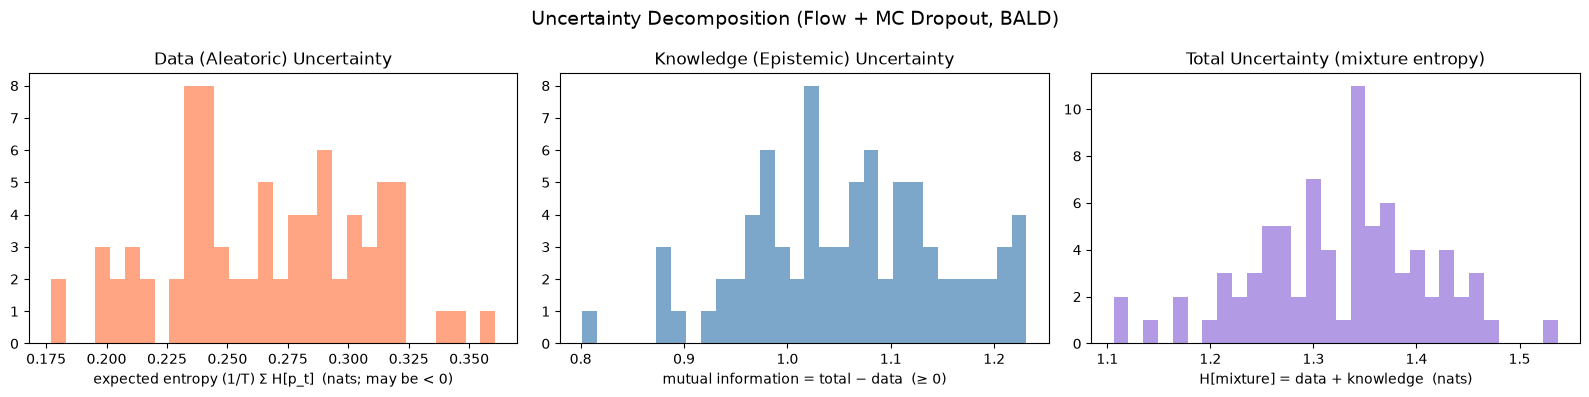

In [6]:
# Visualise the decomposition
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(data_unc, bins=30, alpha=0.7, color="coral")
axes[0].set_title("Data (Aleatoric) Uncertainty")
axes[0].set_xlabel("expected entropy (1/T) Σ H[p_t]  (nats; may be < 0)")

if knowledge_unc is not None:
    axes[1].hist(knowledge_unc, bins=30, alpha=0.7, color="steelblue")
    axes[1].set_title("Knowledge (Epistemic) Uncertainty")
    axes[1].set_xlabel("mutual information = total − data  (≥ 0)")
else:
    axes[1].text(
        0.5, 0.5, "No dropout → no\nknowledge uncertainty", ha="center", va="center", transform=axes[1].transAxes
    )
    axes[1].set_title("Knowledge Uncertainty (N/A)")

total_unc = data_unc + (knowledge_unc if knowledge_unc is not None else 0)
axes[2].hist(total_unc, bins=30, alpha=0.7, color="mediumpurple")
axes[2].set_title("Total Uncertainty (mixture entropy)")
axes[2].set_xlabel("H[mixture] = data + knowledge  (nats)")

fig.suptitle("Uncertainty Decomposition (Flow + MC Dropout, BALD)", fontsize=14)
plt.tight_layout()
plt.show()


### 6.4  Classification uncertainty

Classification uncertainty for both `NODEClassifier` and `MLPHeadClassifier` follows the **exact
information-theoretic decomposition CatBoost uses** (Malinin et al.). Each MC-dropout forward pass
is treated as one *virtual ensemble member* producing a class-probability vector $p_t$, with mean
$\bar p = \tfrac{1}{T}\sum_t p_t$ and Shannon entropy $H(p) = -\sum_c p_c \log p_c$:

$$\underbrace{H(\bar p)}_{\text{total (predictive entropy)}}
= \underbrace{\tfrac{1}{T}\sum_t H(p_t)}_{\text{data (expected entropy, aleatoric)}}
+ \underbrace{\Bigl[H(\bar p) - \tfrac{1}{T}\sum_t H(p_t)\Bigr]}_{\text{knowledge (mutual information, epistemic)}}$$

Column mapping (units are **nats**, comparable within the classifier family only):

| Column | Meaning |
|--------|---------|
| `total_uncertainty` | $H(\bar p)$ — entropy of the mean-over-dropout prediction |
| `data_uncertainty` | $\tfrac{1}{T}\sum_t H(p_t)$ — **mean** per-pass entropy |
| `knowledge_uncertainty` | `total − data` — mutual information ($\ge 0$ by Jensen) |
| `mean_predictions` | mean-over-dropout probability of the reported class |

The key subtlety: **data uncertainty is the *(mean) entropy*, not the *entropy of the mean*** — the
entropy of the mean is the *total*, and their difference is the epistemic term. The additive
identity `total == data + knowledge` holds exactly (up to float32 noise), exactly like CatBoost's
`virtual_ensembles_predict`. Works for **binary *and* multiclass** (CatBoost only does binary).


In [17]:
X_train_c, X_test_c, y_train_c, y_test_c = get_classification_data()

clf_unc = NODEClassifier(
    num_trees=256,
    depth=4,
    input_dropout=0.1,
    max_epochs=20,
    lr=0.01,
    device="cpu",
)
clf_unc.fit(X_train_c, y_train_c)

df_clf_unc = clf_unc.predict_uncertainty(X_test_c, num_samples=30)
print(df_clf_unc.head())

# The CatBoost-aligned decomposition is additive: total == data + knowledge
additive_gap = (
    df_clf_unc["total_uncertainty"] - df_clf_unc["data_uncertainty"] - df_clf_unc["knowledge_uncertainty"]
).abs().max()
print(f"\nMax |total - (data + knowledge)| = {additive_gap:.2e}  (≈ 0 confirms the identity)")
print(f"knowledge ≥ 0 (mutual information): {(df_clf_unc['knowledge_uncertainty'] >= -1e-6).all()}")


Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1        0.6893  0.6846
      2        0.6773  0.1270
      3        0.6668  0.1158
      4        0.6554  0.2545
      5        0.6440  0.2130
      6        0.6299  0.2807
      7        0.6217  0.1551
      8        0.6053  0.1688
      9        0.6006  0.1546
     10        0.5770  0.1720
     11        0.5624  0.1415
     12        0.5531  0.1636
     13        0.5425  0.2525
     14        0.5281  0.1947
     15        0.5109  0.1770
     16        0.4940  0.2225
     17        0.4810  0.1562
     18        0.4726  0.1692
     19        0.4730  0.1701
     20        0.4522  0.2066
   pred  mean_predictions  knowledge_uncertainty  data_uncertainty  \
0     0          0.224679               0.006858          0.525909   
1     0          0.

---
## 7  Learned Embeddings & UMAP

NODE's tree layers learn powerful representations of the input data.
Use `get_embeddings()` to extract them for visualisation or downstream tasks.

The embedding dimension is $m = \text{num\_trees} \times \text{depth}$, so a model
with 256 trees and depth 4 yields 1024-dim embeddings.

```
  Raw Features                     Learned Embeddings
  x ∈ ℝⁿ                          e ∈ ℝᵐ  (m = num_trees × depth)
     │                                ▲
     ▼                                │
 ┌───────────────────────────────────────┐
 │             ODST Ensemble             │
 │  x → [Tree₁  Tree₂  ...  Treeₖ]     │
 │       ↓       ↓            ↓         │
 │      h₁      h₂    ...   hₖ         │
 │       └───────┴──────┬────┘          │
 │                      ▼               │
 │              concat(h₁...hₖ)  ═══► e │
 └───────────────────────────────────────┘
                                     │
                                     ▼
                              Downstream uses:
                        ┌──────────────────────────────┐
                        │  • UMAP / t-SNE visualisation│
                        │  • Clustering (KMeans, etc.) │
                        │  • Transfer to new heads     │
                        │  • Similarity search         │
                        └──────────────────────────────┘
```

In [18]:
# Get embeddings from the classifier trained above
embeddings_train = clf_unc.get_embeddings(X_train_c)
embeddings_test = clf_unc.get_embeddings(X_test_c)

print(f"Embedding shape (train): {embeddings_train.shape}")
print(f"Embedding shape (test):  {embeddings_test.shape}")

Embedding shape (train): (320, 1280)
Embedding shape (test):  (80, 1280)


In [19]:
try:
    from umap import UMAP

    # Combine embeddings and labels
    all_embeddings = np.vstack([embeddings_train, embeddings_test])
    all_labels = np.concatenate([y_train_c, y_test_c])
    all_splits = ["train"] * len(y_train_c) + ["test"] * len(y_test_c)

    # Fit UMAP
    reducer = UMAP(n_components=2, random_state=RANDOM_STATE)
    embeddings_2d = reducer.fit_transform(all_embeddings)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # By class
    for cls in np.unique(all_labels):
        mask = all_labels == cls
        axes[0].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], s=10, alpha=0.6, label=f"Class {cls}")
    axes[0].set_title("NODE Embeddings coloured by class")
    axes[0].legend()

    # By split
    for split, colour in [("train", "steelblue"), ("test", "coral")]:
        mask = np.array(all_splits) == split
        axes[1].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], s=10, alpha=0.6, label=split, color=colour)
    axes[1].set_title("NODE Embeddings coloured by split")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

except ImportError:
    print("Install `umap-learn` for UMAP visualisation: pip install umap-learn")

TypeError: check_array() got an unexpected keyword argument 'ensure_all_finite'. Did you mean 'force_all_finite'?

---
## 8  Multi-Target Regression

NODE supports multi-target regression natively.  When targets contain `NaN` values,
NODE automatically masks them during loss computation, allowing training on
incomplete label matrices.

where $\mathcal{V}_j = \{i : y_{ij} \neq \text{NaN}\}$ is the set of valid samples for target $j$.

```

  Target matrix Y with missing values:$$\mathcal{L} = \sum_{j=1}^{T} w_j \cdot \frac{1}{|\mathcal{V}_j|}\sum_{i \in \mathcal{V}_j}(\hat{y}_{ij} - y_{ij})^2$$



        Target₁  Target₂  Target₃You can also weight each target's contribution to the loss via `task_weights`:

  x₁ [  1.2      NaN      0.8  ]

  x₂ [  0.5      3.1      NaN  ]```

  x₃ [  NaN      2.4      1.1  ]                 Σᵢ Σⱼ  𝟙[yᵢⱼ ≠ NaN]

  x₄ [  0.9      1.7      0.3  ]          ─────────────────────────────────────

      ℒ = Σᵢ Σⱼ  𝟙[yᵢⱼ ≠ NaN] · (ŷᵢⱼ − yᵢⱼ)²

  Loss computation (NaN-masked MSE):

In [ ]:
# Create multi-target data
X_mt, y_mt = make_regression(
    n_samples=400,
    n_features=10,
    n_targets=3,
    noise=10,
    random_state=RANDOM_STATE,
)

# Inject some NaN values to demonstrate masking
y_mt = y_mt.astype(np.float32)
rng = np.random.RandomState(42)
nan_mask = rng.random(y_mt.shape) < 0.1
y_mt[nan_mask] = np.nan
print(f"NaN fraction: {np.isnan(y_mt).mean():.1%}")

X_train_mt, X_test_mt, y_train_mt, y_test_mt = train_test_split(
    X_mt.astype(np.float32),
    y_mt,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

reg_mt = NODERegressor(
    num_trees=256,
    depth=4,
    head_type="mlp",
    target_type="multi_target",
    max_epochs=20,
    lr=0.01,
    device="cpu",
)
reg_mt.fit(X_train_mt, y_train_mt)

preds_mt = reg_mt.predict(X_test_mt)
print(f"\nPredictions shape: {preds_mt.shape}")

# Evaluate per-target (excluding NaN test labels)
for t in range(y_test_mt.shape[1]):
    valid = ~np.isnan(y_test_mt[:, t])
    r2 = r2_score(y_test_mt[valid, t], preds_mt[valid, t])
    print(f"  Target {t}: R² = {r2:.4f}  ({valid.sum()} valid samples)")

NaN fraction: 10.7%
Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1    21780.1875  0.8280
      2    21408.8785  0.1574
      3    21209.6590  0.1676
      4    21058.7980  0.1824
      5    20897.1914  0.1826
      6    20705.0953  0.1364
      7    20412.0953  0.1422
      8    20297.4762  0.1391
      9    20036.2422  0.1464
     10    19692.2188  0.1453
     11    19358.4160  0.2148
     12    19141.8367  0.1340
     13    18766.3391  0.2421
     14    18417.1766  0.1295
     15    18184.7090  0.1533
     16    17738.9746  0.1474
     17    17423.4787  0.1436
     18    17038.8049  0.1423
     19    16526.0988  0.2320
     20    16320.2852  0.1467

Predictions shape: (80, 3)
  Target 0: R² = 0.3043  (70 valid samples)
  Target 1: R² = 0.2492  (76 valid samples)
  Target 2: R² = 0.3032

---
## 9  Class Weights & Imbalanced Data

For imbalanced classification, pass weights to `CrossEntropyLoss`.

In [ ]:
import torch
import torch.nn as nn

# Create imbalanced dataset (90/10 split)
X_train_imb, X_test_imb, y_train_imb, y_test_imb = get_classification_data(
    n=500,
    weights=[0.9, 0.1],
)

print(f"Class distribution (train): {np.bincount(y_train_imb)}")

# Compute class weights (inverse frequency)
counts = np.bincount(y_train_imb)
class_weights = torch.tensor(
    [len(y_train_imb) / (len(counts) * c) for c in counts],
    dtype=torch.float32,
)
print(f"Class weights: {class_weights}")

clf_weighted = NODEClassifier(
    num_trees=256,
    depth=4,
    max_epochs=20,
    lr=0.01,
    device="cpu",
    criterion=nn.CrossEntropyLoss,
    criterion__weight=class_weights,
)
clf_weighted.fit(X_train_imb, y_train_imb)

preds_imb = clf_weighted.predict(X_test_imb)
print(f"\nAccuracy = {accuracy_score(y_test_imb, preds_imb):.4f}")
print(f"Predicted distribution: {np.bincount(preds_imb)}")

Class distribution (train): [362  38]
Class weights: tensor([0.5525, 5.2632])
Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1        0.6875  0.4231
      2        0.6746  0.1059
      3        0.6635  0.1162
      4        0.6510  0.1257
      5        0.6385  0.1357
      6        0.6259  0.2073
      7        0.6121  0.1518
      8        0.5962  0.1629
      9        0.5827  0.1732
     10        0.5650  0.1577
     11        0.5503  0.1493
     12        0.5352  0.1526
     13        0.5253  0.1521
     14        0.5085  0.1553
     15        0.4936  0.1567
     16        0.4781  0.1496
     17        0.4739  0.1993
     18        0.4604  0.2931
     19        0.4491  0.2657
     20        0.4378  0.1927

Accuracy = 0.9000
Predicted distribution: [83 17]


---
## 10  Multi-Label Classification

For tasks where each sample can belong to **multiple classes simultaneously**
(e.g. molecule → multiple activity labels), use `NODEClassifier` with
`model_type="classification_multilabel"` and `BCEWithLogitsLoss`.

| Parameter | Value |
|-----------|-------|
| `model_type` | `"classification_multilabel"` |
| `criterion` | `nn.BCEWithLogitsLoss` |
| `y` shape | `(n_samples, n_labels)` with 0/1 values |
| `predict()` | Thresholded at 0.5 |
| `predict_proba()` | Sigmoid probabilities per label |

In [ ]:
from sklearn.datasets import make_multilabel_classification
import torch.nn as nn

# Generate synthetic multi-label data (each sample can have multiple labels)
X_ml, y_ml = make_multilabel_classification(
    n_samples=400,
    n_features=10,
    n_classes=4,
    n_labels=2,
    random_state=RANDOM_STATE,
)
X_ml = X_ml.astype(np.float32)
y_ml = y_ml.astype(np.float32)

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_ml,
    y_ml,
    test_size=0.2,
    random_state=RANDOM_STATE,
)
print(f"Train: {X_train_ml.shape}, Labels: {y_train_ml.shape}")
print(f"Avg labels/sample: {y_train_ml.sum(axis=1).mean():.1f}")

clf_ml = NODEClassifier(
    num_trees=256,
    depth=4,
    model_type="classification_multilabel",
    criterion=nn.BCEWithLogitsLoss,
    max_epochs=20,
    lr=0.01,
    device="cpu",
)
clf_ml.fit(X_train_ml, y_train_ml)

preds_ml = clf_ml.predict(X_test_ml)  # Binary predictions (threshold 0.5)
probas_ml = clf_ml.predict_proba(X_test_ml)  # Sigmoid probabilities

print(f"\nPredictions shape: {preds_ml.shape}")
print(f"Probabilities shape: {probas_ml.shape}")
print(f"Sample prediction: {preds_ml[0]}")
print(f"Sample proba:      {np.round(probas_ml[0], 3)}")

Train: (320, 10), Labels: (320, 4)
Avg labels/sample: 1.7
Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1        0.6921  0.6652
      2        0.6848  0.1634
      3        0.6776  0.1410
      4        0.6706  0.1663
      5        0.6638  0.1791
      6        0.6570  0.2148
      7        0.6501  0.2526
      8        0.6434  0.2264
      9        0.6361  0.1957
     10        0.6291  0.1964
     11        0.6221  0.1791
     12        0.6149  0.2392
     13        0.6077  0.2720
     14        0.6006  0.2577
     15        0.5936  0.2227
     16        0.5866  0.1779
     17        0.5798  0.1774
     18        0.5731  0.2389
     19        0.5665  0.2979
     20        0.5601  0.1890

Predictions shape: (80, 4)
Probabilities shape: (80, 4)
Sample prediction: [0 1 0 1]
Sample proba:  

---
## 11  Standalone Heads

The head architectures (MLP, Flow) are also available as **standalone sklearn-compatible estimators**.
These are useful when:

- You already have pre-computed embeddings (e.g. from a foundation model)
- You want a lightweight model without the full NODE tree layers
- You want to combine heads with your own feature pipeline

```
  ┌──────────────────────────────────────────────────────────┐
  │                  MLPHeadRegressor                        │
  │                                                          │
  │  Input ──► Linear ──► BN ──► ReLU ──► Drop  ← × layers  │
  │                                         │                │
  │                                    Linear ──► ŷ ∈ ℝᵈ    │
  │                                                          │
  │  Loss: MSE     UQ: MC Dropout (σ across N passes)        │
  └──────────────────────────────────────────────────────────┘

  ┌──────────────────────────────────────────────────────────┐
  │                  MLPHeadClassifier                       │
  │                                                          │
  │  Input ──► Linear ──► BN ──► ReLU ──► Drop  ← × layers  │
  │                                         │                │
  │                                    Linear ──► softmax    │
  │                                                  │       │
  │  Loss: CrossEntropy    UQ: entropy of avg probs  ▼       │
  │                                          P(class | x)    │
  └──────────────────────────────────────────────────────────┘

  ┌──────────────────────────────────────────────────────────┐
  │                  FlowHeadRegressor                       │
  │                                                          │
  │  Input ──context──► Conditional Flow ──► p(y | x)        │
  │                          │                               │
  │                    ┌─────┴─────┐                         │
  │                    │ .sample() │──► regression samples    │
  │                    │.log_prob()│──► NLL uncertainty       │
  │                    └───────────┘                         │
  │  Loss: -log p(y|x)    UQ: aleatoric via NLL             │
  └──────────────────────────────────────────────────────────┘
```

| Class | Task | Key features |
|-------|------|--------------|
| `MLPHeadRegressor` | Regression | AdamW, EarlyStopping, LR scheduling built-in |
| `MLPHeadClassifier` | Classification | Same + CrossEntropyLoss |
| `FlowHeadRegressor` | Probabilistic regression | NLL loss, `predict_flow()` for sampling |

All three support:
- **Auto dimension detection** (via `DimensionSetter` callback – no need to set `input_dim`/`output_dim`)
- **Uncertainty** via `predict_uncertainty()` (MC Dropout)
- **Hyperparameter optimisation** with `suggest_hyperparameters()` + MotherTuner

### 11.1  MLPHeadRegressor

In [ ]:
X_train, X_test, y_train, y_test, y_scaler = get_regression_data()

mlp_reg = MLPHeadRegressor(
    hidden_dims=[128, 64, 32],
    dropout=0.1,
    activation="GELU",
    max_epochs=50,
    lr=0.005,
)
mlp_reg.fit(X_train, y_train)

preds_mlp = mlp_reg.predict(X_test)
print(f"MLPHeadRegressor R² = {r2_score(y_test, preds_mlp.flatten()):.4f}")

Re-initializing module because the following parameters were re-set: module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
Re-initializing module because the following parameters were re-set: activation, batch_norm, dropout, hidden_dims, input_dim, output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss    valid_loss      lr     dur
-------  ------------  ------------  ------  ------
      1        1.0770        0.7618  0.0050  0.8121
      2        0.4431        0.5892  0.0050  0.0126
      3        0.3360        0.3742  0.0050  0.0139
      4        0.2695        0.2433  0.0050  0.0177
      5        0.2588        0.1761  0.0050  0.0176
      6        0.2532        0.1784  0.0050  0.0166
      7        0.2050        0.1925  0.0050  0.0186
      8        0.1827        0.1771  0.0050  0.0172
      9        0.1200        0.1566  0.0050  0.0187
     10        0.1296        0.1235  0.0050  0.0183
     11        0.1086 

In [ ]:
# Standalone MLP head architecture
mlp_reg.module_

### 11.2  MLPHeadClassifier

In [ ]:
X_train_c, X_test_c, y_train_c, y_test_c = get_classification_data(n_classes=3)

mlp_clf = MLPHeadClassifier(
    hidden_dims=[128, 64],
    dropout=0.1,
    activation="ReLU",
    max_epochs=50,
    lr=0.005,
)
mlp_clf.fit(X_train_c, y_train_c)

preds_mlp_clf = mlp_clf.predict(X_test_c)
probas_mlp = mlp_clf.predict_proba(X_test_c)

print(f"MLPHeadClassifier accuracy = {accuracy_score(y_test_c, preds_mlp_clf):.4f}")
print(f"Probability shape: {probas_mlp.shape}")

Re-initializing module because the following parameters were re-set: module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
Re-initializing module because the following parameters were re-set: activation, batch_norm, dropout, hidden_dims, input_dim, output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss    valid_acc    valid_loss      lr     dur
-------  ------------  -----------  ------------  ------  ------
      1        1.1527       0.5625        1.1163  0.0050  0.0421
      2        0.7636       0.6250        0.9869  0.0050  0.0397
      3        0.7407       0.6250        0.8654  0.0050  0.0219
      4        0.6722       0.6562        0.7844  0.0050  0.0385
      5        0.6354       0.6875        0.7192  0.0050  0.0194
      6        0.5940       0.6875        0.6688  0.0050  0.0160
      7        0.5452       0.6875        0.6410  0.0050  0.0307
      8        0.5184       0.7188        0.6274  0.0050  0.0

In [ ]:
# Standalone MLP classifier architecture
mlp_clf.module_

### 11.3  FlowHeadRegressor

In [ ]:
X_train, X_test, y_train, y_test, y_scaler = get_regression_data()

flow_reg = FlowHeadRegressor(
    flow_type="NSF",
    flow_transforms=3,
    flow_bins=8,
    max_epochs=50,
    lr=0.001,
)
flow_reg.fit(X_train, y_train)

# Point predictions
preds_flow_head = flow_reg.predict(X_test)
print(f"FlowHeadRegressor R² = {r2_score(y_test, preds_flow_head.flatten()):.4f}")

# Sample from the predictive distribution
samples = flow_reg.predict_flow(X_test, num_samples=200)
print(f"\nSamples shape: {samples.shape}  (n_test, num_samples, output_dim)")

# Compute quantiles from samples
q025 = np.quantile(samples.squeeze(-1), 0.025, axis=1)
q975 = np.quantile(samples.squeeze(-1), 0.975, axis=1)
print(f"95% credible interval width (mean): {(q975 - q025).mean():.4f}")

Re-initializing module because the following parameters were re-set: module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
Re-initializing module because the following parameters were re-set: flow_bins, flow_components, flow_degree, flow_signal, flow_transforms, flow_type, input_dim, output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss    valid_loss      lr     dur
-------  ------------  ------------  ------  ------
      1        1.4557        1.4680  0.0010  0.1058
      2        1.1975        1.2508  0.0010  0.0662
      3        1.0089        1.0503  0.0010  0.0812
      4        0.8091        0.8339  0.0010  0.0655
      5        0.5922        0.6408  0.0010  0.0711
      6        0.3767        0.4325  0.0010  0.0333
      7        0.1594        0.2234  0.0010  0.0432
      8       -0.0626        0.0858  0.0010  0.0469
      9       -0.2271       -0.0161  0.0010  0.0628
     10       -0.2903       -0.2325  0

In [ ]:
# Standalone Flow head architecture (NSF)
flow_reg.module_

---
## 12  SHAP Explanations

NODE is fully compatible with SHAP for post-hoc feature-importance analysis.
Two explainers work well:

| Explainer | Pros | Cons |
|-----------|------|------|
| **`GradientExplainer`** ✅ recommended | Fast, uses standard PyTorch autograd, works with all heads | Requires tensor inputs |
| **`KernelExplainer`** | Model-agnostic, works with `flow` heads too | Slower (model-agnostic) |

> ⚠️ `DeepExplainer` may fail on NODE because DeepLIFT's custom hooks don't
> recognise NODE's sparse activations (entmax / sparsemax).

In [ ]:
import torch

# --- Train a small NODE for SHAP demos ---------------------------------
X_train, X_test, y_train, y_test, _ = get_regression_data()

node_shap = NODERegressor(
    num_trees=256,
    depth=4,
    head_type="linear",
    max_epochs=20,
    lr=0.01,
    device="cpu",
    verbose=0,
)
node_shap.fit(X_train, y_train)
print(f"Linear-head R²: {r2_score(y_test, node_shap.predict(X_test)):.3f}")

Linear-head R²: 0.981


### 12.1 GradientExplainer (recommended)

`GradientExplainer` uses standard PyTorch autograd so it handles NODE's custom
operations (sparsemax, entmax, ODST) without issues.

SHAP values shape: (20, 10)


ValueError: Axes has not been added yet

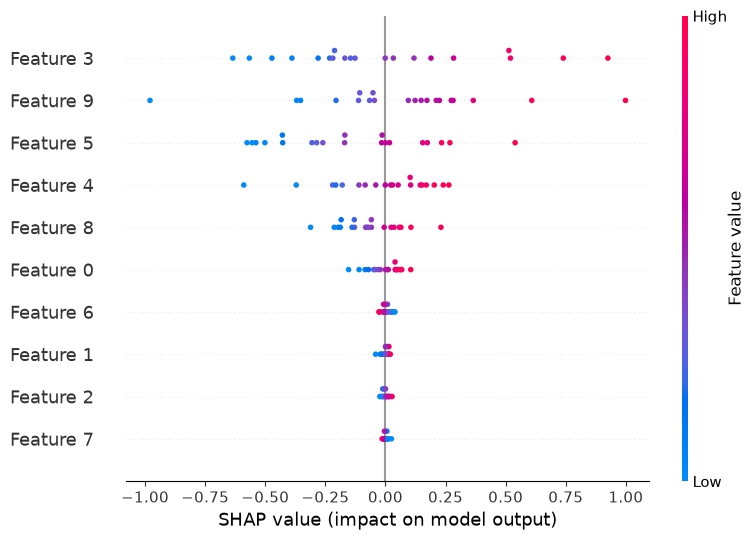

In [ ]:
try:
    import shap

    # Background data for expected-value estimation
    background_tensor = torch.tensor(X_train[:50], dtype=torch.float32)
    test_tensor = torch.tensor(X_test[:20], dtype=torch.float32)

    explainer = shap.GradientExplainer(node_shap.module_, background_tensor)
    shap_values = explainer.shap_values(test_tensor)

    # Squeeze if extra dim present (single-target regression)
    if hasattr(shap_values, "shape") and len(shap_values.shape) == 3:
        shap_values = shap_values.squeeze(-1)

    print(f"SHAP values shape: {shap_values.shape}")

    # shap.summary_plot manages its own figure, so render each plot separately
    # (forcing them into pre-made subplots via plt.sca invalidates the axes).
    # --- Dot plot: per-feature impact ---
    shap.summary_plot(shap_values, X_test[:20], show=False)
    plt.title("Feature Impact (dot plot)")
    plt.tight_layout()
    plt.show()

    # --- Bar plot: mean |SHAP| ---
    shap.summary_plot(shap_values, X_test[:20], plot_type="bar", show=False)
    plt.title("Mean |SHAP| (bar plot)")
    plt.tight_layout()
    plt.show()

except ImportError:
    print("Install shap for explanations:  pip install shap")

### 12.2 Waterfall plot — explaining a single prediction

The waterfall plot shows how each feature pushes the prediction away from the
base value (average model output on the background set).

In [ ]:
try:
    import shap

    sample_idx = 0
    sample_shap = shap_values[sample_idx]

    # Base value = mean model output on background
    with torch.no_grad():
        base_value = float(node_shap.module_(background_tensor).cpu().numpy().mean())

    explanation = shap.Explanation(
        values=sample_shap,
        base_values=base_value,
        data=X_test[sample_idx],
    )

    pred = float(node_shap.predict(X_test[sample_idx : sample_idx + 1])[0])
    true = float(y_test[sample_idx])
    print(f"Sample {sample_idx}  —  true={true:.2f}  pred={pred:.2f}")

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(explanation, show=False)
    plt.title(f"Waterfall — sample {sample_idx}  (true={true:.2f}, pred={pred:.2f})")
    plt.tight_layout()
    plt.show()

except ImportError:
    print("Install shap for explanations:  pip install shap")

### 12.3 SHAP with MLP head

`GradientExplainer` also works with the MLP head — the autograd tape handles
the extra linear + BatchNorm + activation layers seamlessly.

In [ ]:
try:
    import shap

    node_mlp_shap = NODERegressor(
        num_trees=256,
        depth=4,
        head_type="mlp",
        mlp_hidden_dims=[64, 32],
        max_epochs=20,
        lr=0.01,
        device="cpu",
        verbose=0,
    )
    node_mlp_shap.fit(X_train, y_train)
    print(f"MLP-head R²: {r2_score(y_test, node_mlp_shap.predict(X_test)):.3f}")

    explainer_mlp = shap.GradientExplainer(
        node_mlp_shap.module_,
        torch.tensor(X_train[:50], dtype=torch.float32),
    )
    shap_mlp = explainer_mlp.shap_values(
        torch.tensor(X_test[:20], dtype=torch.float32),
    )
    if hasattr(shap_mlp, "shape") and len(shap_mlp.shape) == 3:
        shap_mlp = shap_mlp.squeeze(-1)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_mlp, X_test[:20], show=False)
    plt.title("SHAP Summary — MLP Head (GradientExplainer)")
    plt.tight_layout()
    plt.show()
    print("✅ GradientExplainer works with all NODE head types!")

except ImportError:
    print("Install shap for explanations:  pip install shap")

### 12.4 KernelExplainer — model-agnostic fallback

For **flow heads** (which return distributions, not point predictions),
use `KernelExplainer` with the model's `predict` method.
It is slower but works with *any* head type.

In [ ]:
try:
    import shap

    background = shap.kmeans(X_train, 50)
    kernel_explainer = shap.KernelExplainer(node_shap.predict, background)

    # Explain a handful of test samples
    shap_kernel = kernel_explainer.shap_values(X_test[:10])
    # Ensure 2-D array (some shap versions return a list for single-output)
    if isinstance(shap_kernel, list):
        shap_kernel = shap_kernel[0]

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_kernel, X_test[:10], show=False)
    plt.title("SHAP Summary — KernelExplainer (model-agnostic)")
    plt.tight_layout()
    plt.show()

    print("💡 Tip: Use KernelExplainer for flow heads where GradientExplainer")
    print("   cannot be applied (flow heads return distributions, not tensors).")

except ImportError:
    print("Install shap for explanations:  pip install shap")

### 12.5 Detailed SHAP Visualizations

Below we combine the GradientExplainer SHAP values (computed in §12.1) into
richer plots:

- **Beeswarm** — density-aware dot plot of per-feature SHAP impacts
- **Heatmap** — sample × feature SHAP matrix
- **Dependence plot** — SHAP value vs. feature value for a single feature, coloured by the strongest interaction

In [ ]:
try:
    import shap

    # Build a proper SHAP Explanation object from the GradientExplainer results
    # (shap_values and X_test[:20] were computed in §12.1)
    with torch.no_grad():
        base_val = float(node_shap.module_(torch.tensor(X_train[:50], dtype=torch.float32)).cpu().numpy().mean())

    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]
    explanation = shap.Explanation(
        values=shap_values,  # (20, 10)
        base_values=np.full(20, base_val),
        data=X_test[:20],
        feature_names=feature_names,
    )

    # --- 1. Beeswarm plot (density-aware dot plot) ---
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.plots.beeswarm(explanation, show=False)
    plt.title("Beeswarm — per-sample feature contributions")
    plt.tight_layout()
    plt.show()

    # --- 2. Heatmap (sample × feature matrix) ---
    fig, ax = plt.subplots(figsize=(12, 6))
    shap.plots.heatmap(explanation, show=False)
    plt.title("SHAP Heatmap — samples × features")
    plt.tight_layout()
    plt.show()

    # --- 3. Dependence plot for the most important feature ---
    top_feature = int(np.abs(shap_values).mean(axis=0).argmax())
    fig, ax = plt.subplots(figsize=(8, 5))
    shap.dependence_plot(
        top_feature,
        shap_values,
        X_test[:20],
        feature_names=feature_names,
        ax=ax,
        show=False,
    )
    ax.set_title(f"Dependence — {feature_names[top_feature]} (strongest interaction colour)")
    plt.tight_layout()
    plt.show()

    print("✅ All SHAP visualizations rendered successfully.")

except ImportError:
    print("Install shap for explanations:  pip install shap")

---
## 13  Advanced Topics

### 13.1  DataFrame & Categorical Support

NODE natively accepts **pandas DataFrames**. Categorical columns must be **declared explicitly**
via the `cat_features` argument (mirroring CatBoost's `cat_features`) — there is **no automatic
dtype-based detection**. Any non-numeric column that is *not* listed in `cat_features` raises a
`ValueError`, so the contract is always explicit:

```python
import pandas as pd

df = pd.DataFrame({
    "mass":      [150.0, 220.0, 310.0],
    "logP":      [2.1, 3.5, 1.2],
    "scaffold":  ["benzene", "pyridine", "benzene"],
})

reg = NODERegressor(cat_features=["scaffold"])   # declare categoricals explicitly
reg.fit(df, y)          # scaffold label-encoded + embedded
preds = reg.predict(df)
```

The `InputOutputShapeSetter` callback then handles:
- Input dimension from `X.shape[1]`
- Applying the declared `cat_features` as categorical columns
- Label encoding and embedding-dimension calculation

### 13.2  Embeddings → Standalone Head Pipeline

Use NODE's tree layers as a **feature extractor**, then feed the learned
embeddings into a standalone head or any downstream model:

```python
# 1. Train NODE
node = NODERegressor(num_trees=2048, max_epochs=100, device="cpu")
node.fit(X_train, y_train)

# 2. Extract embeddings
emb_train = node.get_embeddings(X_train)
emb_test  = node.get_embeddings(X_test)

# 3. Feed into a standalone flow head for probabilistic output
flow = FlowHeadRegressor(flow_type="NSF", max_epochs=200)
flow.fit(emb_train, y_train)
samples = flow.predict_flow(emb_test, num_samples=500)
```

This two-stage approach lets you decouple representation learning from the
prediction head, or reuse expensive embeddings with multiple heads.

### 13.3  Skorch Integration

NODE estimators are built on [skorch](https://github.com/skorch-dev/skorch),
so all skorch features work out of the box — custom callbacks, learning-rate
schedulers, validation splits, etc.

```python
from skorch.callbacks import EarlyStopping, LRScheduler

reg = NODERegressor(
    callbacks=[
        EarlyStopping(patience=10, monitor="valid_loss"),
        LRScheduler(policy="CosineAnnealingLR", T_max=50),
    ],
    train_split=skorch.dataset.ValidSplit(cv=0.15),
)
```

### 13.4  Device Management

```python
# Auto-detect GPU (uses CUDA if available, else CPU)
reg = NODERegressor()

# Force CPU (useful for CI / small models)
reg = NODERegressor(device="cpu")

# Specify a particular GPU
reg = NODERegressor(device="cuda:0")
```

### 13.5  MC Dropout — Implementation Details

NODE's MC-dropout is deliberately *surgical* about which modules become stochastic at inference:

1. **The model stays in `eval()` mode.** This is the crucial subtlety — it means every
   `BatchNorm1d` layer keeps using its **frozen running statistics** and its running stats are
   **never updated** by the extra forward passes. Only the dropout paths inject randomness, so the
   MC variance reflects genuine model uncertainty rather than shifting normalisation.
2. **Dropout is re-enabled by directly flipping `.training = True`** (not by calling `.train()`) on
   exactly three module types: the top NODE module (for `tree_dropout`), each `DenseODSTBlock` (for
   `input_dropout`), and every `nn.Dropout` in the MLP head (for `mlp_dropout`). Everything else —
   including BatchNorm — stays in eval mode.
3. **Automatic deterministic fallback.** If *all* dropout rates are 0, there is nothing to sample,
   so `predict_uncertainty()` returns the deterministic prediction with zero variance instead of
   wastefully running `num_samples` identical passes.

The net effect: reliable epistemic estimates from a single trained model, **without retraining** and
**without corrupting the learned BatchNorm statistics**.

### 13.6  Interface Compatibility with Other Mother Estimators

NODE's `predict_uncertainty()` uses the same signature as TabPFN, RandomForest,
and CatBoost on the `ranker_update` branch:

```python
# All Mother estimators share this interface:
results = model.predict_uncertainty(X)
#   → DataFrame with: mean_predictions, knowledge_uncertainty,
#                      data_uncertainty, total_uncertainty

results, q = model.predict_uncertainty(
    X, return_quantiles=True, quantiles=[0.025, 0.5, 0.975],
)
#   → (DataFrame, ndarray of shape (n_samples, n_quantiles))

unc = model.predict_uncertainty(X, uncertainty_for_opt=True)
#   → pd.Series of total_uncertainty (for optimisation loops)
```

NODE additionally provides `predict_quantiles()` as a convenience shorthand and
`predict_with_combined_uncertainty()` for flow-head decomposition.


---
## 14  Hyperparameter Tuning with MotherTuner

NODE plugs directly into Mother's `MotherTuner` for automated hyperparameter optimisation via
Optuna. NODE ships its own `hyperparameter_space` (architecture, dropout, learning-rate and
head-specific ranges), so you do **not** write a suggestion function by hand — the space is derived
from the estimator inside the pipeline.

The API follows the standard Mother pattern (identical to the `test_fast_mother_tuner` unit test):

1. Wrap the estimator in a `PipelineWithHyperparameterRooting` so its search space and defaults are
   discoverable.
2. Construct `MotherTuner(scorer=..., tuning_direction=..., n_trials_optuna=..., n_startup_trials=...)`
   — note the **scorer and Optuna settings live on the tuner**, while the data and CV splitter are
   passed to `optimize()`.
3. Call `tuner.optimize(estimator=pipeline, X=X_df, y=y_series, cross_validation=cv,
   default_parameters=pipeline.default_parameters())`. It returns a **fitted, tuned pipeline**.
4. Inspect results via `tuner.study` (`.best_trial.params`, `.best_trial.value`).

```python
import pandas as pd
from sklearn.model_selection import KFold
from mother.optimization import MotherTuner
from mother.ml import PipelineWithHyperparameterRooting

pipeline = PipelineWithHyperparameterRooting(
    [("regressor", NODERegressor(max_epochs=50, device="cpu"))]
)

tuner = MotherTuner(
    scorer="neg_mean_squared_error",   # sklearn scorer name or callable
    tuning_direction="maximize",       # maximise the (negative) MSE
    n_trials_optuna=30,
    n_startup_trials=5,                 # first trial(s) evaluate the defaults
)

best_pipeline = tuner.optimize(
    estimator=pipeline,
    X=X_df,                            # pandas DataFrame
    y=y_series,                        # pandas Series
    cross_validation=KFold(n_splits=3, shuffle=True, random_state=42),
    default_parameters=pipeline.default_parameters(),
)

print(f"Best value : {tuner.study.best_trial.value:.4f}")
print(f"Best params: {tuner.study.best_trial.params}")

# `best_pipeline` is already refit — use it directly
preds = best_pipeline.predict(X_df)
```

The cell below runs a **tiny** version (2 trials, 32 trees, 2-fold CV) so it finishes quickly.


In [ ]:
import pandas as pd
from sklearn.model_selection import KFold
from mother.optimization import MotherTuner
from mother.ml import PipelineWithHyperparameterRooting

# Small dataset + DataFrame/Series inputs (required by MotherTuner)
X_train, X_test, y_train, y_test, y_scaler = get_regression_data()
X_df = pd.DataFrame(X_train, columns=[f"feature_{i}" for i in range(X_train.shape[1])])
y_series = pd.Series(y_train.ravel(), name="target")

# NOTE: Optuna explores num_trees in the hundreds–thousands, so we keep
# max_epochs tiny here purely for demo speed. Increase both for real tuning.
pipeline = PipelineWithHyperparameterRooting(
    [("regressor", NODERegressor(num_trees=32, depth=4, max_epochs=1, device="cpu"))]
)

tuner = MotherTuner(
    scorer="neg_mean_squared_error",
    tuning_direction="maximize",
    n_trials_optuna=2,      # tiny for demo speed
    n_startup_trials=1,
)

best_pipeline = tuner.optimize(
    estimator=pipeline,
    X=X_df,
    y=y_series,
    cross_validation=KFold(n_splits=2, shuffle=True, random_state=42),
    default_parameters=pipeline.default_parameters(),
)

print(f"Completed trials : {len(tuner.study.trials)}")
print(f"Best trial value : {tuner.study.best_trial.value:.4f}")
print(f"Best params      : {tuner.study.best_trial.params}")

# The returned pipeline is already refit and ready to predict
preds = best_pipeline.predict(X_df)
print(f"Predictions shape: {preds.shape}")


---
## Summary

| Feature | API |
|---------|-----|
| Regression | `NODERegressor(head_type="mlp").fit(X, y).predict(X)` |
| Classification | `NODEClassifier(head_type="subset").fit(X, y).predict(X)` |
| Multi-label classification | `NODEClassifier(model_type="classification_multilabel", criterion=BCEWithLogitsLoss)` |
| Probabilistic regression | `NODERegressor(head_type="flow", flow_type="NSF")` |
| Uncertainty (standardised) | `.predict_uncertainty(X, num_samples=100)` → DataFrame |
| Uncertainty + quantiles | `.predict_uncertainty(X, return_quantiles=True, quantiles=[...])` → `(DataFrame, ndarray)` |
| Uncertainty for optimisation | `.predict_uncertainty(X, uncertainty_for_opt=True)` → `pd.Series` |
| Quantile shorthand | `.predict_quantiles(X, quantiles=[0.025, 0.5, 0.975])` → ndarray |
| Combined UQ decomposition | `.predict_with_combined_uncertainty(X)` (flow only) |
| Embeddings | `.get_embeddings(X)` |
| DataFrame / categoricals | `NODERegressor(cat_features=["col"]).fit(df, y)` — categoricals declared explicitly |
| Embeddings → head pipeline | `FlowHeadRegressor().fit(node.get_embeddings(X), y)` |
| Standalone MLP (reg) | `MLPHeadRegressor(hidden_dims=[128,64])` |
| Standalone MLP (clf) | `MLPHeadClassifier(hidden_dims=[128,64])` |
| Standalone Flow (reg) | `FlowHeadRegressor(flow_type="NSF")` |
| Hyperparameter tuning | `MotherTuner(scorer=...).optimize(PipelineWithHyperparameterRooting([("regressor", NODERegressor())]), X, y, cv)` |
| SHAP explanations | `shap.GradientExplainer(model.module_, background)` |
| Skorch callbacks | `NODERegressor(callbacks=[EarlyStopping(...), LRScheduler(...)])` |
